In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats.qmc import Sobol

# Global parameters
S0    = 100.0
K     = 100.0
r     = 0.05
sigma = 0.2
T     = 1.0

# Use the SAME N grid
N_values = np.array([1_000, 5_000, 10_000, 50_000, 100_000, 1_000_000])

# Black–Scholes analytic price
def black_scholes_call(S0, K, r, sigma, T):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

price_bs = black_scholes_call(S0, K, r, sigma, T)
price_bs


np.float64(10.450583572185565)

In [ ]:
def std_vs_N(method_fn, N_values, price_true, runs=30, seed=123):
    """
    For each N in N_values, run method_fn 'runs' times and
    return std deviation of (estimate - price_true).
    """
    rng = np.random.default_rng(seed)
    std_list = []

    for N in N_values:
        errors = []
        for _ in range(runs):
            # fresh RNG for each run
            local_rng = np.random.default_rng(rng.integers(0, 1_000_000_000))
            # if method accepts rng, pass it; otherwise call it
            if 'rng' in method_fn.__code__.co_varnames:
                est = method_fn(N, S0, K, r, sigma, T, rng=local_rng)
            else:
                est = method_fn(N, S0, K, r, sigma, T)
            errors.append(est - price_true)
        std_list.append(np.std(errors, ddof=1))
    return np.array(std_list)


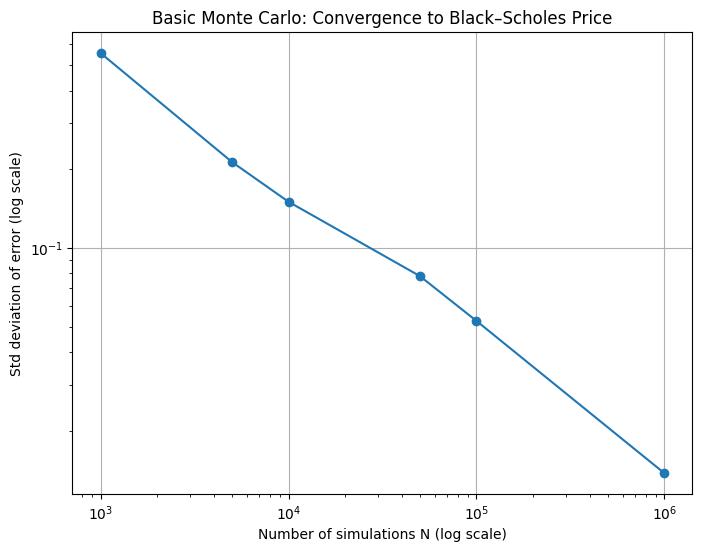

In [ ]:
def mc_call_basic(N, S0, K, r, sigma, T, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    Z  = rng.standard_normal(N)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    X  = np.exp(-r * T) * np.maximum(ST - K, 0.0)
    return np.mean(X)

# Experiment for basic MC
std_basic = std_vs_N(mc_call_basic, N_values, price_bs, runs=30)

plt.figure(figsize=(8, 6))
plt.plot(N_values, std_basic, marker='o')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of simulations N (log scale)')
plt.ylabel('Std deviation of error (log scale)')
plt.title('Basic Monte Carlo: Convergence to Black–Scholes Price')
plt.grid(True)
plt.show()


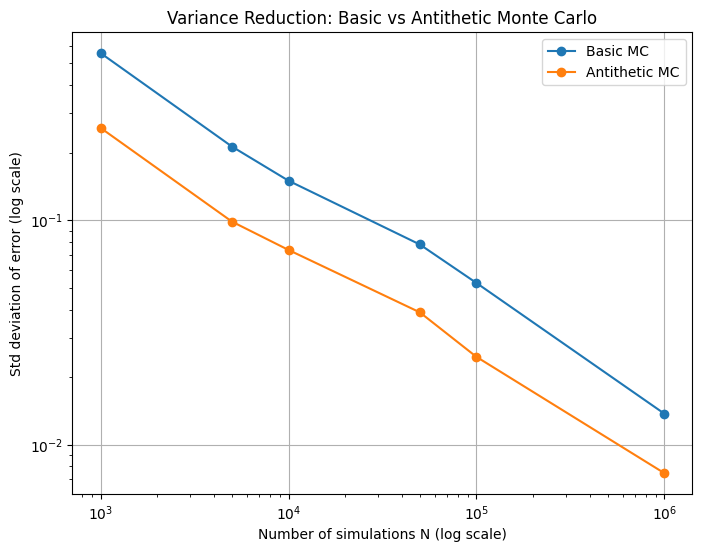

In [ ]:
def mc_call_antithetic(N, S0, K, r, sigma, T, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    Z = rng.standard_normal(N)

    ST_plus  = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    ST_minus = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * (-Z))

    X_plus  = np.exp(-r * T) * np.maximum(ST_plus  - K, 0.0)
    X_minus = np.exp(-r * T) * np.maximum(ST_minus - K, 0.0)

    X_pair = 0.5 * (X_plus + X_minus)
    return np.mean(X_pair)

# Experiment: basic vs antithetic
std_basic = std_vs_N(mc_call_basic,      N_values, price_bs, runs=30)
std_anti  = std_vs_N(mc_call_antithetic, N_values, price_bs, runs=30)

plt.figure(figsize=(8, 6))
plt.plot(N_values, std_basic, marker='o', label='Basic MC')
plt.plot(N_values, std_anti,  marker='o', label='Antithetic MC')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of simulations N (log scale)')
plt.ylabel('Std deviation of error (log scale)')
plt.title('Variance Reduction: Basic vs Antithetic Monte Carlo')
plt.grid(True)
plt.legend()
plt.show()


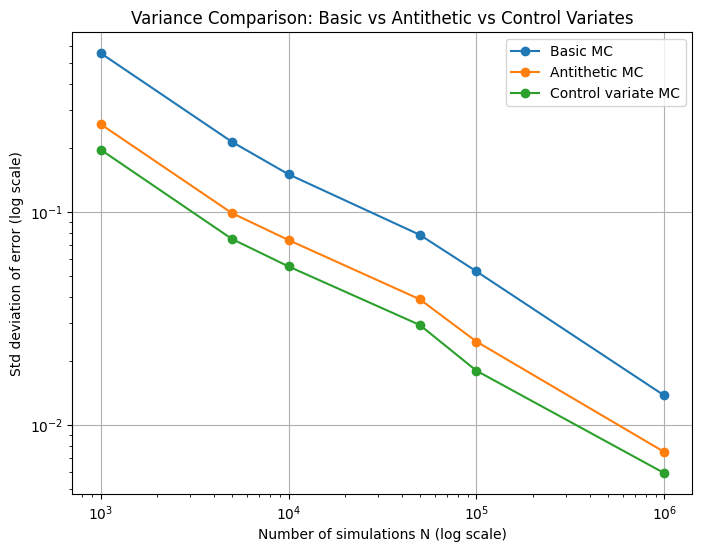

In [ ]:
def mc_call_control_variate(N, S0, K, r, sigma, T, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    Z  = rng.standard_normal(N)

    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    X  = np.exp(-r * T) * np.maximum(ST - K, 0.0)

    Y  = ST                      # control variate
    EY = S0 * np.exp(r * T)      # E[S_T] under risk-neutral measure

    cov_xy = np.cov(X, Y, ddof=1)[0, 1]
    var_y  = np.var(Y, ddof=1)
    beta   = cov_xy / var_y

    C_cv = X - beta * (Y - EY)
    return np.mean(C_cv)

# Experiment: Basic vs Antithetic vs Control variate
std_basic = std_vs_N(mc_call_basic,          N_values, price_bs, runs=30)
std_anti  = std_vs_N(mc_call_antithetic,     N_values, price_bs, runs=30)
std_cv    = std_vs_N(mc_call_control_variate, N_values, price_bs, runs=30)

plt.figure(figsize=(8, 6))
plt.plot(N_values, std_basic, marker='o', label='Basic MC')
plt.plot(N_values, std_anti,  marker='o', label='Antithetic MC')
plt.plot(N_values, std_cv,    marker='o', label='Control variate MC')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of simulations N (log scale)')
plt.ylabel('Std deviation of error (log scale)')
plt.title('Variance Comparison: Basic vs Antithetic vs Control Variates')
plt.grid(True)
plt.legend()
plt.show()


/tmp/ipykernel_135176/223657405.py:3: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  u = sampler.random(n=N)[:, 0]   # N Sobol points in (0,1)


N=   1000: Basic=0.55607, Anti=0.25804, CV=0.19593, QMC=0.02224
N=   5000: Basic=0.21310, Anti=0.09865, CV=0.07461, QMC=0.00423
N=  10000: Basic=0.15011, Anti=0.07376, CV=0.05546, QMC=0.00228
N=  50000: Basic=0.07801, Anti=0.03887, CV=0.02945, QMC=0.00058
N= 100000: Basic=0.05258, Anti=0.02463, CV=0.01797, QMC=0.00025
N=1000000: Basic=0.01375, Anti=0.00747, CV=0.00594, QMC=0.00002


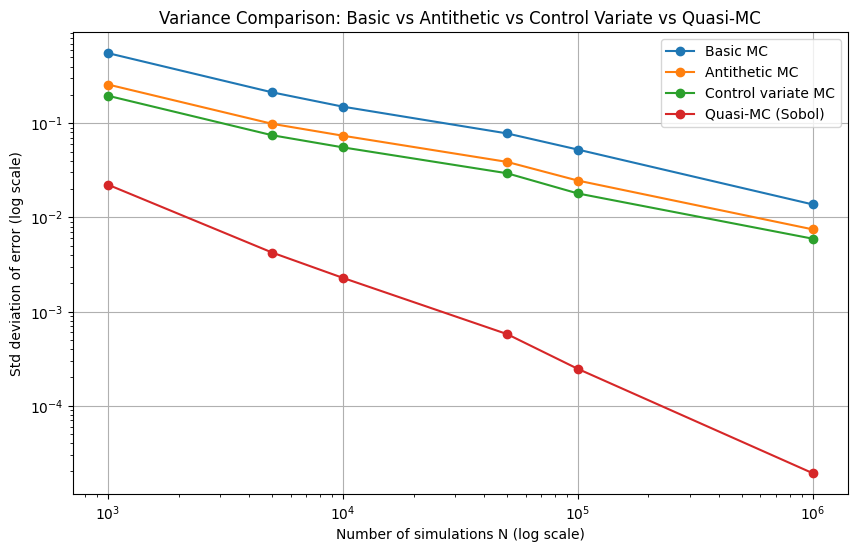

In [ ]:
def quasi_Z(N, d=1):
    sampler = Sobol(d=d, scramble=True)
    u = sampler.random(n=N)[:, 0]   # N Sobol points in (0,1)
    Z = norm.ppf(u)                 # map to N(0,1)
    return Z

def mc_call_quasi(N, S0, K, r, sigma, T):
    Z  = quasi_Z(N, d=1)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    X  = np.exp(-r * T) * np.maximum(ST - K, 0.0)
    return np.mean(X)

# Experiment: all four methods
std_basic = std_vs_N(mc_call_basic,          N_values, price_bs, runs=30)
std_anti  = std_vs_N(mc_call_antithetic,     N_values, price_bs, runs=30)
std_cv    = std_vs_N(mc_call_control_variate, N_values, price_bs, runs=30)
std_qmc   = std_vs_N(mc_call_quasi,          N_values, price_bs, runs=30)

for N, sb, sa, sc, sq in zip(N_values, std_basic, std_anti, std_cv, std_qmc):
    print(f"N={N:7d}: Basic={sb:.5f}, Anti={sa:.5f}, CV={sc:.5f}, QMC={sq:.5f}")

plt.figure(figsize=(10, 6))
plt.plot(N_values, std_basic, marker='o', label='Basic MC')
plt.plot(N_values, std_anti,  marker='o', label='Antithetic MC')
plt.plot(N_values, std_cv,    marker='o', label='Control variate MC')
plt.plot(N_values, std_qmc,   marker='o', label='Quasi-MC (Sobol)')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of simulations N (log scale)')
plt.ylabel('Std deviation of error (log scale)')
plt.title('Variance Comparison: Basic vs Antithetic vs Control Variate vs Quasi-MC')
plt.grid(True)
plt.legend()
plt.show()
